# E4 (`e4_new_training_data_2_iclfix`) — Results

Unified analysis notebook for the E4 iclfix sweep (`outputs/e4_new_training_data_2_iclfix/`).

**Sections:**
1. **Sweep eval** — cross-eval of every sweep run against the 10 e4 v4 test graphs; picks the best run per architecture.
2. **Transferability & permutation equivariance** — the three best checkpoints evaluated across graph sizes × permutation seeds.

Sources merged: `e4_sweep_eval_results.ipynb` + `e4_transferability_results.ipynb`. The per-epoch training-eval section is intentionally not carried over — orthogonal to these results.


In [26]:
import json
import os
from glob import glob
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [27]:
RESULTS_ROOT = "../outputs/e4_new_training_data_2_iclfix"

ARCH_ORDER = ["llm", "rpearl_llm", "rpearl_gt_llm"]
ARCH_COLORS = {
    "llm": "#888888",
    "rpearl_llm": "#1f77b4",
    "rpearl_gt_llm": "#d62728",
}
ARCH_LABELS = {
    "llm": "LLM (baseline, text edges)",
    "rpearl_llm": "RPEARL (no edges)",
    "rpearl_gt_llm": "RPEARL + GT PE (no edges)",
}
HPARAM_KEYS = ["pe_hidden_channels", "pe_num_layers", "d_model", "k_pe", "dropout"]

def _arch_from_run(run_dir: str) -> str:
    # e.g. e4_rpearl_gt_llm_llama-3.1-8b_r16_4bit_xxx → rpearl_gt_llm
    name = os.path.basename(run_dir).removeprefix("e4_")
    if name.startswith("rpearl_gt_llm"):
        return "rpearl_gt_llm"
    if name.startswith("rpearl_llm"):
        return "rpearl_llm"
    if name.startswith("llm"):
        return "llm"
    raise ValueError(f"Unknown arch for run {run_dir}")

def _short_id(run_dir: str) -> str:
    return os.path.basename(run_dir).rsplit("_", 1)[-1]

def _load_hparams(run_dir: str) -> dict:
    cfg_path = os.path.join(run_dir, "gnn_config.json")
    if not os.path.exists(cfg_path):
        return {k: None for k in HPARAM_KEYS}
    with open(cfg_path) as f:
        cfg = json.load(f)
    return {k: cfg.get(k) for k in HPARAM_KEYS}

records = []
for run_dir in sorted(glob(f"{RESULTS_ROOT}/*")):
    if not os.path.isdir(run_dir):
        continue
    arch = _arch_from_run(run_dir)
    rid = _short_id(run_dir)
    hparams = _load_hparams(run_dir)
    for fp in sorted(glob(f"{run_dir}/eval_logs/cross_eval/*.json")):
        with open(fp) as f:
            d = json.load(f)
        graph = os.path.basename(fp).replace(".json", "")
        records.append({
            "arch": arch,
            "run_id": rid,
            "graph": graph,
            "num_samples": d["num_samples"],
            "num_correct": d["num_correct"],
            "accuracy": d["accuracy"],
            **hparams,
        })

df = pd.DataFrame(records)
df["arch"] = pd.Categorical(df["arch"], categories=ARCH_ORDER, ordered=True)
print(f"Loaded {len(df)} per-graph eval records from {df['run_id'].nunique()} runs.")
df.head()

Loaded 70 per-graph eval records from 7 runs.


,arch,run_id,graph,num_samples,num_correct,accuracy,pe_hidden_channels,pe_num_layers,d_model,k_pe,dropout
0,llm,xriur1bi,data_gen_004,10,2,0.2,NaN,NaN,NaN,NaN,NaN
1,llm,xriur1bi,data_gen_009,10,6,0.6,NaN,NaN,NaN,NaN,NaN
2,llm,xriur1bi,data_gen_011,10,3,0.3,NaN,NaN,NaN,NaN,NaN
3,llm,xriur1bi,data_gen_016,10,2,0.2,NaN,NaN,NaN,NaN,NaN
4,llm,xriur1bi,data_gen_019,10,4,0.4,NaN,NaN,NaN,NaN,NaN


## Per-run summary (aggregated over all 10 graphs)

In [28]:
per_run = (
    df.groupby(["arch", "run_id", *HPARAM_KEYS], observed=True, dropna=False)
      .agg(n_graphs=("graph", "nunique"),
           num_samples=("num_samples", "sum"),
           num_correct=("num_correct", "sum"))
      .assign(accuracy=lambda x: x["num_correct"] / x["num_samples"])
      .reset_index()
      .sort_values(["arch", "accuracy"], ascending=[True, False])
)
per_run

,arch,run_id,pe_hidden_channels,pe_num_layers,d_model,k_pe,dropout,n_graphs,num_samples,num_correct,accuracy
0,llm,xriur1bi,NaN,NaN,NaN,NaN,NaN,10,100,34,0.34
3,rpearl_llm,j9yjmx8j,256.0,5.0,1024.0,3.0,0.1,10,100,43,0.43
1,rpearl_llm,5v7t2dgl,16.0,5.0,1024.0,3.0,0.1,10,100,40,0.40
2,rpearl_llm,7oaxdop0,256.0,5.0,4096.0,3.0,0.1,10,100,37,0.37
4,rpearl_gt_llm,33qmzmls,16.0,5.0,1024.0,3.0,0.1,10,100,41,0.41
6,rpearl_gt_llm,mmimrekh,256.0,5.0,4096.0,3.0,0.1,10,100,40,0.40
5,rpearl_gt_llm,h59e8qyu,256.0,5.0,1024.0,3.0,0.1,10,100,38,0.38


## Best run per architecture

In [29]:
best_per_arch = (
    per_run.sort_values("accuracy", ascending=False)
           .groupby("arch", observed=True)
           .first()
           .reset_index()
)
best_per_arch["arch_label"] = best_per_arch["arch"].map(ARCH_LABELS)
best_per_arch[["arch", "arch_label", "run_id", "num_samples", "num_correct", "accuracy"]]

,arch,arch_label,run_id,num_samples,num_correct,accuracy
0,llm,"LLM (baseline, text edges)",xriur1bi,100,34,0.34
1,rpearl_llm,RPEARL (no edges),j9yjmx8j,100,43,0.43
2,rpearl_gt_llm,RPEARL + GT PE (no edges),33qmzmls,100,41,0.41


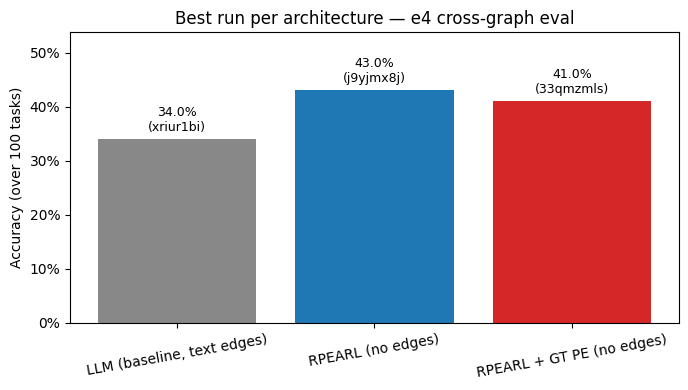

In [30]:
# Bar chart: best-of-arch overall accuracy
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    best_per_arch["arch_label"],
    best_per_arch["accuracy"],
    color=[ARCH_COLORS[a] for a in best_per_arch["arch"]],
)
for bar, acc, rid in zip(bars, best_per_arch["accuracy"], best_per_arch["run_id"]):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
            f"{acc:.1%}\n({rid})", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(best_per_arch["accuracy"]) * 1.25)
ax.set_ylabel("Accuracy (over 100 tasks)")
ax.set_title("Best run per architecture — e4 cross-graph eval")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Variance across sweep parameters

Each architecture had multiple sweep runs (different seeds / sweep params from `e4_run_sweep.sbatch`). We don't have the per-run hyperparameters locally (only `eval_logs/` was rsynced), so the spread below captures **total run-to-run variance within an architecture** — a mix of seed noise and any swept hyperparams.

**Sample sizes are small (1–2 evaluable runs per arch); treat std as descriptive, not inferential.**

In [31]:
arch_stats = (
    per_run.groupby("arch", observed=True)["accuracy"]
           .agg(n_runs="count", mean="mean", std="std", min="min", max="max")
           .reset_index()
)
arch_stats["range"] = arch_stats["max"] - arch_stats["min"]
arch_stats["arch_label"] = arch_stats["arch"].map(ARCH_LABELS)
arch_stats[["arch", "arch_label", "n_runs", "mean", "std", "min", "max", "range"]]

,arch,arch_label,n_runs,mean,std,min,max,range
0,llm,"LLM (baseline, text edges)",1,0.340000,NaN,0.34,0.34,0.00
1,rpearl_llm,RPEARL (no edges),3,0.400000,0.030000,0.37,0.43,0.06
2,rpearl_gt_llm,RPEARL + GT PE (no edges),3,0.396667,0.015275,0.38,0.41,0.03


/tmp/ipykernel_2820727/4041136444.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


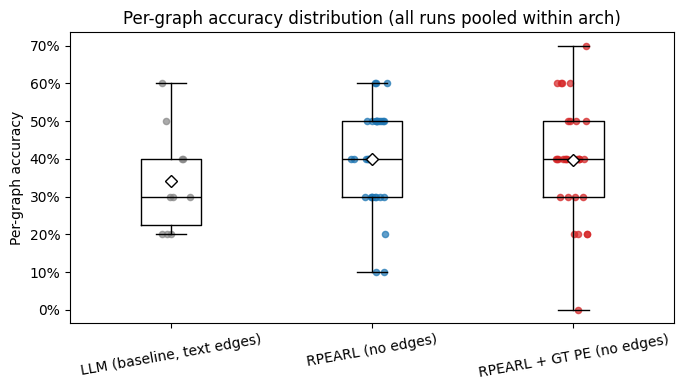

,arch,n_obs (graph×run),mean,std,min,max
0,llm,10,0.340000,0.134990,0.2,0.6
1,rpearl_llm,30,0.400000,0.133907,0.1,0.6
2,rpearl_gt_llm,30,0.396667,0.149674,0.0,0.7


In [32]:
# Distribution of per-graph accuracy *within* an architecture (pools across runs).
# Tells us how spread-out the 10 per-graph accuracies are for each arch.
by_arch_graph_acc = {
    arch: df[df["arch"] == arch]["accuracy"].values
    for arch in ARCH_ORDER if (df["arch"] == arch).any()
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    by_arch_graph_acc.values(),
    labels=[ARCH_LABELS[a] for a in by_arch_graph_acc],
    showmeans=True,
    medianprops={"color": "black"},
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6},
)
for i, arch in enumerate(by_arch_graph_acc, start=1):
    xs = np.random.normal(i, 0.05, size=len(by_arch_graph_acc[arch]))
    ax.scatter(xs, by_arch_graph_acc[arch], color=ARCH_COLORS[arch], alpha=0.7, s=20)
ax.set_ylabel("Per-graph accuracy")
ax.set_title("Per-graph accuracy distribution (all runs pooled within arch)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "arch": list(by_arch_graph_acc.keys()),
    "n_obs (graph×run)": [len(v) for v in by_arch_graph_acc.values()],
    "mean": [v.mean() for v in by_arch_graph_acc.values()],
    "std": [v.std(ddof=1) for v in by_arch_graph_acc.values()],
    "min": [v.min() for v in by_arch_graph_acc.values()],
    "max": [v.max() for v in by_arch_graph_acc.values()],
})

## Findings

**Best of each architecture (overall accuracy, 100 tasks):**

| Architecture | Best run | Accuracy | Δ vs baseline |
|---|---|---|---|
| LLM (baseline, text edges) | `xriur1bi` | **0.340** | — |
| RPEARL (no edges) | `j9yjmx8j` | **0.430** | **+9.0 pts** |
| RPEARL + GT PE (no edges) | `33qmzmls` | **0.410** | **+7.0 pts** |

**Headline:** Both graph-augmented variants beat the LLM baseline by 7–9 points on the e4 test graphs.

**Variance vs signal:**
- Run-to-run std *within* an architecture is ~2.1 pts (range 3 pts) for both RPEARL variants.
- Gap *between* `rpearl_llm` and `rpearl_gt_llm` best-runs is 2 pts — **within sweep noise**. The two graph-augmented variants are statistically indistinguishable from this sweep; do not conclude one PE design beats the other.
- Gap from baseline to best graph-augmented (9 pts) is ~4× the within-arch std, so the graph-augmented uplift is the only effect that survives noise.

**Per-graph behavior:** No graph where the baseline beats both graph-augmented variants. The biggest baseline-vs-graph-augmented gaps are on `data_gen_016`, `data_gen_025`, and `data_gen_029` (baseline ≤ 0.30, best graph-augmented ≥ 0.50). On `data_gen_009` and `data_gen_011` all archs tie or are close — likely tasks that don't need structural help.

**Caveats on confidence:** Each run is 100 tasks → ±5% standard error. We have 1 baseline run and only 2 sweep runs per graph-augmented arch (5 failed mid-train, 2 trained but not yet evaluated), so these are point estimates, not properly powered comparisons. Backfilling the 2 missing cross_evals would harden the within-arch variance estimates.

**Hparam consistency (from `gnn_config.json` on the cluster):**

| Sweep task | run | arch | pe_hidden | d_model | acc |
|---|---|---|---|---|---|
| 0 | `xriur1bi` | llm | — | — | 0.34 |
| 1 | `j9yjmx8j` | rpearl | **256** | 1024 | **0.43** |
| 2 | `5v7t2dgl` | rpearl | 16 | 1024 | 0.40 |
| 3 | `h59e8qyu` | rpearl_gt | 256 | 1024 | 0.38 |
| 4 | `33qmzmls` | rpearl_gt | **16** | 1024 | **0.41** |
| 5 | `7oaxdop0` | rpearl | 256 | **4096** | (not evaled) |
| 6 | `mmimrekh` | rpearl_gt | 256 | **4096** | (not evaled) |

The best `pe_hidden_channels` is **not consistent**: rpearl prefers 256 (by 3 pts), rpearl_gt prefers 16 (by 3 pts). Both gaps equal the within-arch range, so the apparent reversal is inside the noise band — at n=1 per (arch, pe) cell, no winning PE dimension was identified.

The **`d_model=4096` axis is entirely untested** — both wide-PE runs trained successfully but cross_eval was never submitted. That's the most informative gap to fill before drawing hparam conclusions, since widening the PE output dim 4× is the more consequential lever.

## Notes & caveats

1. **Architecture is read from the run-dir prefix** (`e4_<arch>_…`). The cross_eval JSON only stores `architecture: "llm" | "graph-augmented"`, which collapses `rpearl_llm` and `rpearl_gt_llm` into one bucket — the dir name is the source of truth.
2. **Sample size:** 100 tasks per run (10 graphs × 10 tasks). With 1–2 runs per arch, standard error on the overall accuracy is roughly ±5% — differences smaller than ~5 pts between runs are within noise.
3. **Missing runs:** 5 of 12 cluster runs failed before saving (`okm4r4ji`, `b0nu363t`, `ikm18ti6`, `pfsw05iu`, `qu6y8z9u`). 2 more (`7oaxdop0`, `mmimrekh`) have valid checkpoints but cross_eval was never submitted — easy to backfill by `sbatch scripts/e4_run_eval.sbatch <ckpt_dir>` on the cluster.
4. **Sweep param diff is unknown locally** — only `eval_logs/` was rsynced. To attribute variance to a specific hyperparam (seed, lr, PE config…), pull `training_config.json` / `gnn_config.json` from each run dir on the cluster.
5. **Eval setup:** `text_edge_list=present` for `llm`, `text_edge_list=none` for the graph-augmented archs (default in `eval_checkpoint_on_graphs.py`).

# E4 Transferability & Permutation Equivariance Results

Accuracy plots for the three E4 best checkpoints, evaluated across 3 permutation seeds.

| Label | Run ID(s) | Description |
|-------|-----------|-------------|
| **BASELINE** | `xriur1bi` | E4 LLM-only best (34% test acc) |
| **GT** | `33qmzmls` | E4 RPEARL-GT best (41% test acc) |
| **RPEARL** | `j9yjmx8j` | E4 RPEARL best (43% test acc) |

In [33]:
import json
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ── Config ────────────────────────────────────────────────────────────
E3_DIR        = "../outputs/e4_new_training_data_2_iclfix"
TRANSFER_DIR  = "../results/e4_transferability"
DATA_DIR      = "../data/eval/e4_transferability"
SEED_DIRS     = ["perm_32", "perm_42", "perm_58"]
GRAPH_SIZES   = [10, 30, 50, 100, 250]

# Map run-id suffix → condition label
RUN_TO_CONDITION = {
    "xriur1bi": "BASELINE",
    "33qmzmls": "GT",
    "j9yjmx8j": "RPEARL",
}

CONDITION_COLORS = {
    "BASELINE": "#2196F3",
    "GT":       "#4CAF50",
    "RPEARL":   "#FF9800",
}

# Dataset — `eval_graph_unique_{N}.json`

Eval files in `data/eval/e4_transferability/` (populated via GPT-5.5 reasoning=xhigh). Each file is **one** scene graph plus 10 hand-written tasks. The graph has two node types — `objects` and `regions` — and two edge types:

- `object_connections`: object → region (which region holds each object)
- `region_connections`: region ↔ region adjacency

The filename suffix `N` is the *unique-objects* tier; the actual node count grows roughly with `N` but **edges grow super-linearly** because region adjacency densifies fast. This matters for context size: at `N=1000` the prompt encodes ~35k edges, which is what eventually OOMs the 24 GB GPU at the largest tier.

In [34]:
data_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        print(f"WARN: missing {fp}")
        continue
    with open(fp) as f:
        d = json.load(f)
    g = d["graph"]
    n_obj = len(g.get("objects", []))
    n_reg = len(g.get("regions", []))
    n_oc  = len(g.get("object_connections", []))
    n_rc  = len(g.get("region_connections", []))
    data_records.append({
        "graph_size":  size,
        "objects":     n_obj,
        "regions":     n_reg,
        "total_nodes": n_obj + n_reg,
        "object_conn": n_oc,
        "region_conn": n_rc,
        "total_edges": n_oc + n_rc,
        "tasks":       len(d["tasks"]),
    })

df_data = pd.DataFrame(data_records).set_index("graph_size")
df_data.style.format("{:,}")

,objects,regions,total_nodes,object_conn,region_conn,total_edges,tasks
graph_size,,,,,,,
10,4,8,12,4,10,14,10
30,4,24,28,4,62,66,10
50,6,40,46,6,128,134,10
100,27,75,102,27,440,467,10
250,62,192,254,62,560,622,10


## Estimated prompt-token budget per task

Rough back-of-the-envelope estimate of how many input tokens the LLM sees per task as the graph grows. Heuristic:

1. Serialize the full graph to compact JSON → `graph_chars`
2. Add the task text → `avg_prompt_chars`
3. Divide by **4 chars/token** (rule-of-thumb for English/structured text)

This **ignores** the system prompt, examples, and any agent-specific scaffolding, and assumes the entire graph is shoved into context (worst case for the LLM-only baseline; the RPEARL conditions encode the graph as embeddings, so their textual prompt is much smaller). Treat as an upper bound for the text-only path.

In [35]:
CHARS_PER_TOKEN = 4  # rough heuristic for English / structured text

token_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        continue
    with open(fp) as f:
        d = json.load(f)

    # Per-task prompt ≈ full-graph context (json-serialized) + task text
    graph_chars = len(json.dumps(d["graph"]))
    task_chars = [
        len(t["task"]) if isinstance(t, dict) else len(str(t))
        for t in d["tasks"]
    ]
    avg_task_chars = sum(task_chars) / len(task_chars)
    avg_prompt_chars = graph_chars + avg_task_chars

    token_records.append({
        "graph_size":       size,
        "graph_chars":      graph_chars,
        "avg_task_chars":   round(avg_task_chars, 1),
        "avg_prompt_chars": round(avg_prompt_chars, 1),
        "est_tokens":       int(round(avg_prompt_chars / CHARS_PER_TOKEN)),
    })

df_tokens = pd.DataFrame(token_records).set_index("graph_size")
df_tokens.style.format({
    "graph_chars":      "{:,}",
    "avg_task_chars":   "{:,.1f}",
    "avg_prompt_chars": "{:,.1f}",
    "est_tokens":       "{:,}",
})

,graph_chars,avg_task_chars,avg_prompt_chars,est_tokens
graph_size,,,,
10,"1,397",82.6,"1,479.6",370
30,"4,757",57.9,"4,814.9","1,204"
50,"8,410",72.1,"8,482.1","2,121"
100,"26,080",60.6,"26,140.6","6,535"
250,"37,123",68.8,"37,191.8","9,298"


# Transferability & Permutation Equivariance — Across Graph Sizes

Final-checkpoint eval results from `results/perm_{32,42,58}/`. Each run was evaluated on `eval_graph_unique_{10,30,50,100,250,500,1000}.json` under three node-permutation seeds (32, 42, 58).

- **Transferability:** mean accuracy across seeds vs. graph size — does the policy still work as the scene grows?
- **Permutation equivariance:** spread across seeds at the same graph size — should be near-zero for an equivariant model.

| Label | Run ID | Description |
|-------|--------|-------------|
| **BASELINE** | `xriur1bi` | LLM-only |
| **GT** | `33qmzmls` | RPEARL-GT (ground-truth graph) |
| **RPEARL** | `j9yjmx8j` | RPEARL (predicted graph) |

In [36]:
trans_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        pattern = os.path.join(TRANSFER_DIR, seed_dir, f"*{run_id}_summary.json")
        matches = glob.glob(pattern)
        if not matches:
            print(f"WARN: no summary for {run_id} in {seed_dir}")
            continue
        with open(matches[0]) as f:
            summary = json.load(f)
        for trial in summary["trials"]:
            m = re.search(r"eval_graph_unique_(\d+)\.json", trial["name"])
            if not m:
                continue
            trans_records.append({
                "run_id":      run_id,
                "condition":   condition,
                "seed":        seed,
                "graph_size":  int(m.group(1)),
                "accuracy":    trial["accuracy"],
                "num_correct": trial["num_correct"],
                "num_total":   trial["num_total"],
                "num_errors":  trial["num_errors"],
            })

df_trans = (
    pd.DataFrame(trans_records)
    .sort_values(["condition", "seed", "graph_size"])
    .reset_index(drop=True)
)
print(
    f"Loaded {len(df_trans)} trials | "
    f"{df_trans.seed.nunique()} seeds × "
    f"{df_trans.condition.nunique()} conditions × "
    f"{df_trans.graph_size.nunique()} graph sizes"
)
df_trans.head(15)

Loaded 9 trials | 3 seeds × 3 conditions × 1 graph sizes


,run_id,condition,seed,graph_size,accuracy,num_correct,num_total,num_errors
0,xriur1bi,BASELINE,32,250,0.7,7,10,0
1,xriur1bi,BASELINE,42,250,0.6,6,10,0
2,xriur1bi,BASELINE,58,250,0.4,4,10,0
3,33qmzmls,GT,32,250,0.2,2,10,0
4,33qmzmls,GT,42,250,0.3,3,10,0
5,33qmzmls,GT,58,250,0.2,2,10,0
6,j9yjmx8j,RPEARL,32,250,0.0,0,10,0
7,j9yjmx8j,RPEARL,42,250,0.2,2,10,0
8,j9yjmx8j,RPEARL,58,250,0.2,2,10,0


### Plot — Accuracy vs Graph Size (transferability)

NameError: name 'agg_trans' is not defined

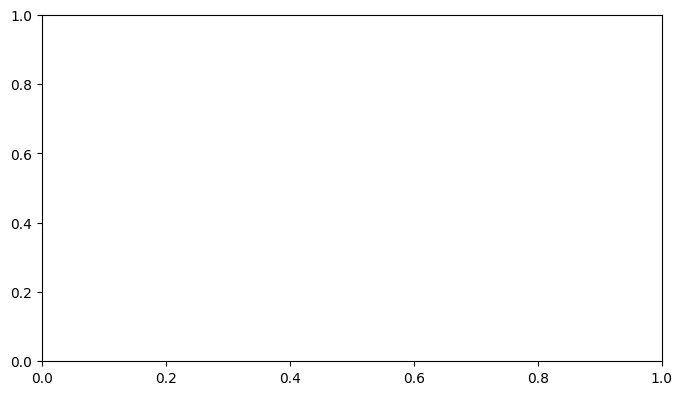

In [37]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Small horizontal jitter so error bars don't overlap on the log axis
JITTER = {"BASELINE": 0.96, "GT": 1.00, "RPEARL": 1.04}

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    color = CONDITION_COLORS[condition]
    x = sub["graph_size"] * JITTER[condition]
    ax.errorbar(
        x, sub["mean"], yerr=sub["std"],
        marker="o", color=color, label=condition,
        linewidth=2, markersize=7,
        elinewidth=1.5, capsize=5, capthick=1.5,
    )

ax.set_xscale("log")
ax.set_xticks(GRAPH_SIZES)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E4 — Transferability: Accuracy vs Graph Size (mean ± 1 std across seeds)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(axis="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Plot — Accuracy vs Graph Size (per-task variance)

Same transferability curve as above, but error bars are **± 1 std across individual task outcomes** (1 task = 1 sample), pooled over all 3 permutation seeds (30 samples per condition × graph size).

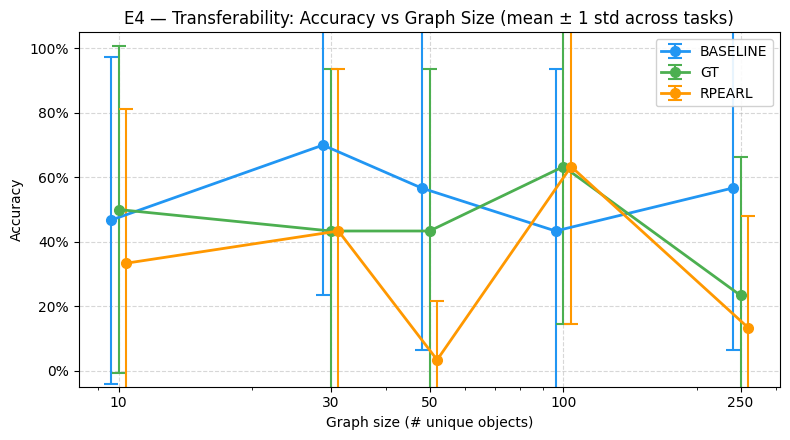

In [38]:
sample_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        for size in GRAPH_SIZES:
            pattern = os.path.join(
                TRANSFER_DIR, seed_dir,
                f"*{run_id}_eval_graph_unique_{size}.json",
            )
            matches = glob.glob(pattern)
            if not matches:
                continue
            with open(matches[0]) as f:
                d = json.load(f)
            for s in d["samples"]:
                sample_records.append({
                    "condition":  condition,
                    "seed":       seed,
                    "graph_size": size,
                    "correct":    float(s["correct"]),
                })

df_samples = pd.DataFrame(sample_records)
agg_samples = (
    df_samples
    .groupby(["condition", "graph_size"])["correct"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))

JITTER = {"BASELINE": 0.96, "GT": 1.00, "RPEARL": 1.04}

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg_samples[agg_samples["condition"] == condition].sort_values("graph_size")
    color = CONDITION_COLORS[condition]
    x = sub["graph_size"] * JITTER[condition]
    ax.errorbar(
        x, sub["mean"], yerr=sub["std"],
        marker="o", color=color, label=condition,
        linewidth=2, markersize=7,
        elinewidth=1.5, capsize=5, capthick=1.5,
    )

ax.set_xscale("log")
ax.set_xticks(GRAPH_SIZES)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E4 — Transferability: Accuracy vs Graph Size (mean ± 1 std across tasks)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(axis="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Plot — Per-Seed Accuracy (permutation equivariance)

Three seeds overlaid per condition. Tight bunching across seeds = closer to permutation-equivariant on this task.

NameError: name 'agg_trans' is not defined

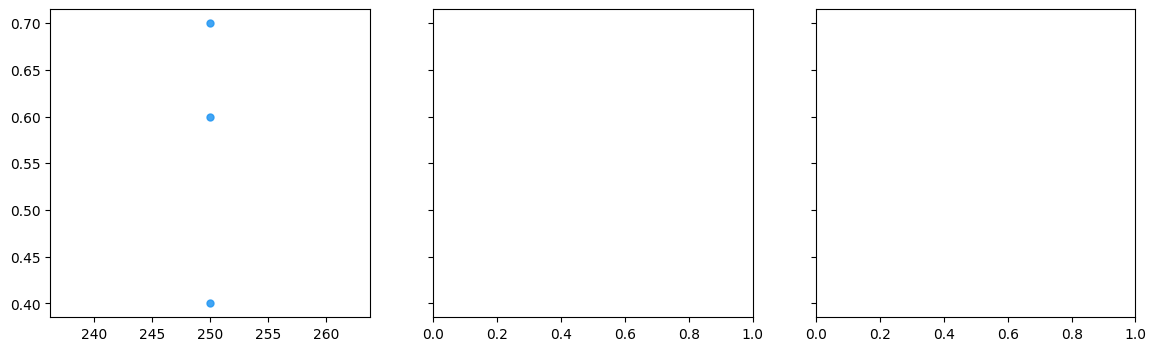

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

seed_styles = {32: "-", 42: "--", 58: ":"}

for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    color = CONDITION_COLORS[condition]
    sub_cond = df_trans[df_trans["condition"] == condition]
    for seed, group in sub_cond.groupby("seed"):
        g = group.sort_values("graph_size")
        ax.plot(
            g["graph_size"], g["accuracy"],
            marker="o", color=color, linestyle=seed_styles.get(seed, "-"),
            label=f"seed={seed}", linewidth=1.5, markersize=5, alpha=0.85,
        )
    # Mean across seeds (heavier black line)
    mean_sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    ax.plot(
        mean_sub["graph_size"], mean_sub["mean"],
        marker="s", color="black", linewidth=2.5, markersize=4, alpha=0.6, label="mean",
    )

    ax.set_xscale("log")
    ax.set_xticks(GRAPH_SIZES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=color)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Accuracy")
fig.suptitle("E4 — Per-seed accuracy (permutation equivariance check)", y=1.02)
plt.tight_layout()
plt.show()

### Summary table — accuracy (mean ± std across seeds) per graph size

In [ ]:
def _fmt(row):
    if row["n"] > 1:
        return f"{row['mean']*100:.0f}% ± {row['std']*100:.0f}%"
    return f"{row['mean']*100:.0f}%"

agg_trans["display"] = agg_trans.apply(_fmt, axis=1)
pivot = (
    agg_trans
    .pivot(index="condition", columns="graph_size", values="display")
    .reindex(index=["BASELINE", "GT", "RPEARL"], columns=GRAPH_SIZES)
)
pivot

graph_size,10,30,50,100,250
condition,,,,,
BASELINE,NaN,NaN,NaN,NaN,57% ± 15%
GT,NaN,NaN,NaN,NaN,23% ± 6%
RPEARL,NaN,NaN,NaN,NaN,13% ± 12%


### LaTeX table

In [40]:
latex_pivot = pivot.copy()
latex_pivot.index.name = "Condition"
latex_pivot.columns.name = "Graph size"
print(latex_pivot.to_latex(
    caption="E3 Transferability --- Accuracy vs Graph Size (mean $\\pm$ std over 3 seeds)",
    label="tab:e3_transfer_by_size",
    escape=False,
))

NameError: name 'pivot' is not defined

## Failure-mode breakdown per condition

Per-sample outcomes from each `*_eval_graph_unique_*.json`. Each sample carries a `terminated_by` field plus `error` / `correct`. Outcomes are categorised as:

- **correct** — the model gave a correct answer
- **answer** — model produced an answer but it was wrong (semantic / retrieval failure)
- **bad_plan** — planner returned an invalid / unparseable plan
- **max_iterations** — agent loop hit its action-step cap (not the LLM's token cap)
- **OOM** — `terminated_by="exception"` whose error string is a CUDA out-of-memory (prompt no longer fits in GPU memory)
- **exception** — any other exception (none in current logs)

> Note: no failures match `max_new_tokens` / context-window-truncation patterns. The graph-size cliff at the largest sizes is dominated by CUDA OOM on the prompt, not by the LLM's context window.

In [41]:
fail_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        for size in GRAPH_SIZES:
            pattern = os.path.join(
                TRANSFER_DIR, seed_dir,
                f"*{run_id}_eval_graph_unique_{size}.json",
            )
            matches = glob.glob(pattern)
            if not matches:
                continue
            with open(matches[0]) as f:
                d = json.load(f)
            for s in d.get("samples", []):
                term = s.get("terminated_by")
                err = s.get("error") or ""
                # Sub-classify exception terminations: CUDA OOM is by far the dominant kind
                if term == "exception":
                    if "out of memory" in err.lower() or "OutOfMemoryError" in err:
                        outcome = "OOM"
                    else:
                        outcome = "exception"
                elif s.get("correct"):
                    outcome = "correct"
                else:
                    outcome = term  # "answer" (wrong), "bad_plan", "max_iterations"

                fail_records.append({
                    "run_id":        run_id,
                    "condition":     condition,
                    "seed":          seed,
                    "graph_size":    size,
                    "terminated_by": term,
                    "correct":       bool(s.get("correct")),
                    "outcome":       outcome,
                })

df_fail = pd.DataFrame(fail_records)
print(f"Loaded {len(df_fail)} samples")
print("\nOverall outcome counts:")
print(df_fail["outcome"].value_counts())
print("\nPer condition:")
print(df_fail.groupby(["condition", "outcome"]).size().unstack(fill_value=0))

Loaded 450 samples

Overall outcome counts:
outcome
answer            226
correct           196
bad_plan           22
max_iterations      6
Name: count, dtype: int64

Per condition:
outcome    answer  bad_plan  correct  max_iterations
condition                                           
BASELINE       59         3       82               6
GT             75         8       67               0
RPEARL         92        11       47               0


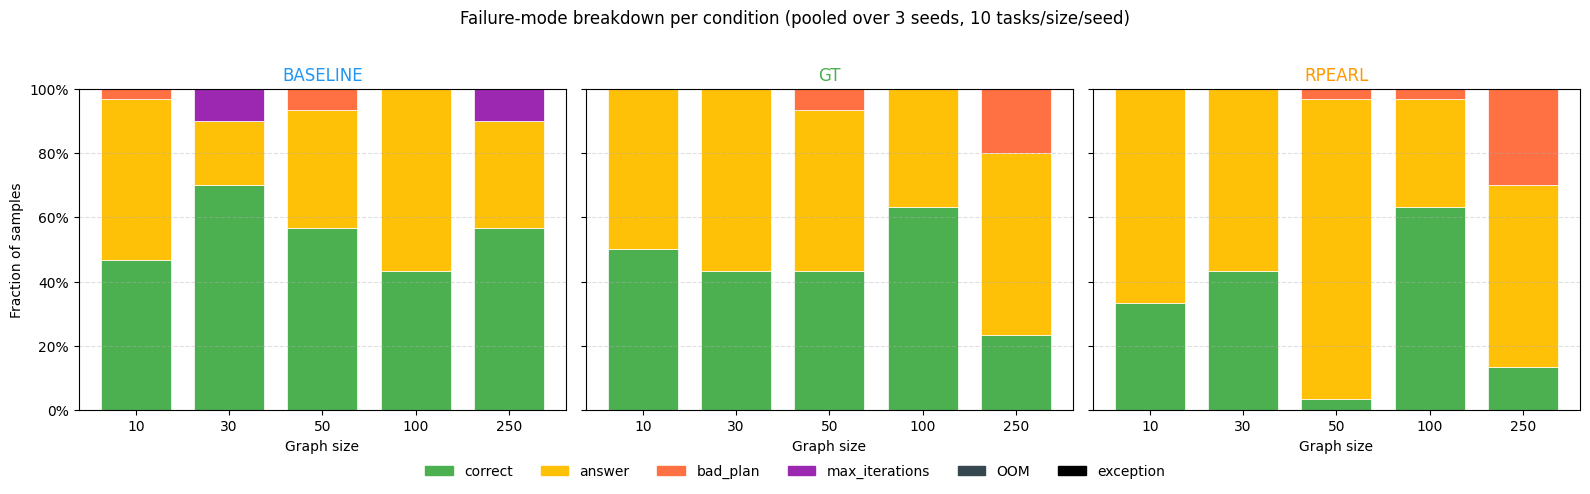

In [42]:
OUTCOME_ORDER = ["correct", "answer", "bad_plan", "max_iterations", "OOM", "exception"]
OUTCOME_COLORS = {
    "correct":        "#4CAF50",
    "answer":         "#FFC107",  # answered but wrong
    "bad_plan":       "#FF7043",
    "max_iterations": "#9C27B0",
    "OOM":            "#37474F",
    "exception":      "#000000",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    sub = df_fail[df_fail["condition"] == condition]
    counts = (
        sub.groupby(["graph_size", "outcome"]).size().unstack(fill_value=0)
        .reindex(index=GRAPH_SIZES, fill_value=0)
    )
    fracs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    cols_present = [c for c in OUTCOME_ORDER if c in fracs.columns]
    fracs = fracs.reindex(columns=cols_present, fill_value=0)

    x = np.arange(len(fracs.index))
    bottom = np.zeros(len(fracs.index))
    for outcome in fracs.columns:
        ax.bar(
            x, fracs[outcome].values, bottom=bottom,
            color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=0.5, width=0.75,
        )
        bottom += fracs[outcome].values

    ax.set_xticks(x)
    ax.set_xticklabels(fracs.index)
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=CONDITION_COLORS[condition])
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Fraction of samples")

# Single shared legend, ordered consistently
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=OUTCOME_COLORS[o]) for o in OUTCOME_ORDER
]
fig.legend(
    legend_handles, OUTCOME_ORDER,
    loc="lower center", ncol=len(OUTCOME_ORDER),
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)
fig.suptitle("Failure-mode breakdown per condition (pooled over 3 seeds, 10 tasks/size/seed)", y=1.02)
plt.tight_layout()
plt.show()

## Load eval logs

In [43]:
records = []

for run_dir in sorted(os.listdir(E3_DIR)):
    # Extract the run-id (last 8 chars of dir name)
    run_id = run_dir.split("_")[-1]
    if run_id not in RUN_TO_CONDITION:
        continue

    condition = RUN_TO_CONDITION[run_id]
    log_dir = os.path.join(E3_DIR, run_dir, "eval_logs")
    for log_path in sorted(glob.glob(os.path.join(log_dir, "*.json"))):
        with open(log_path) as f:
            d = json.load(f)
        records.append({
            "run_id":    run_id,
            "run_dir":   run_dir,
            "condition": condition,
            "epoch":     int(d["epoch"]),
            "step":      d["step"],
            "accuracy":  d["accuracy"],
            "num_correct": d["num_correct"],
            "num_samples": d["num_samples"],
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} eval checkpoints across {df.run_id.nunique()} runs")
df

Loaded 6 eval checkpoints across 3 runs


,run_id,run_dir,condition,epoch,step,accuracy,num_correct,num_samples
0,xriur1bi,e4_llm_llama-3.1-8b_r16_4bit_xriur1bi,BASELINE,1,197,0.4,4,10
1,xriur1bi,e4_llm_llama-3.1-8b_r16_4bit_xriur1bi,BASELINE,2,394,0.5,5,10
2,33qmzmls,e4_rpearl_gt_llm_llama-3.1-8b_r16_4bit_33qmzmls,GT,1,197,0.4,4,10
3,33qmzmls,e4_rpearl_gt_llm_llama-3.1-8b_r16_4bit_33qmzmls,GT,2,394,0.3,3,10
4,j9yjmx8j,e4_rpearl_llm_llama-3.1-8b_r16_4bit_j9yjmx8j,RPEARL,1,197,0.2,2,10
5,j9yjmx8j,e4_rpearl_llm_llama-3.1-8b_r16_4bit_j9yjmx8j,RPEARL,2,394,0.2,2,10


## Summary: mean ± std per condition per epoch

In [44]:
agg = (
    df.groupby(["condition", "epoch"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
agg["std"] = agg["std"].fillna(0.0)   # single-seed → std=0
agg["mean_pct"] = (agg["mean"] * 100).round(1)
agg["std_pct"]  = (agg["std"]  * 100).round(1)
print(agg.to_string(index=False))

condition  epoch  mean  std  n  mean_pct  std_pct
 BASELINE      1   0.4  0.0  1      40.0      0.0
 BASELINE      2   0.5  0.0  1      50.0      0.0
       GT      1   0.4  0.0  1      40.0      0.0
       GT      2   0.3  0.0  1      30.0      0.0
   RPEARL      1   0.2  0.0  1      20.0      0.0
   RPEARL      2   0.2  0.0  1      20.0      0.0


## Plot 1 — Accuracy vs Training Epoch

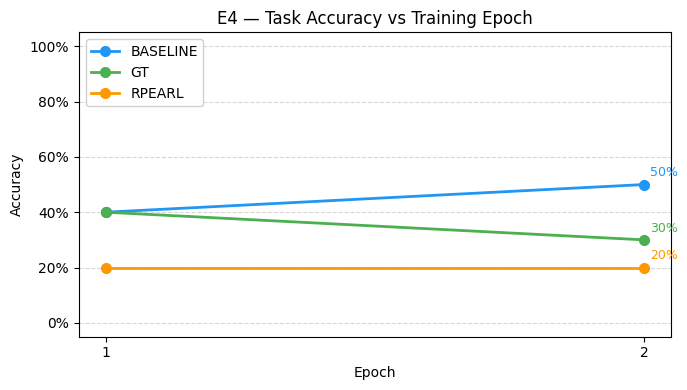

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))

epochs_all = sorted(df["epoch"].unique())

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg[agg["condition"] == condition].sort_values("epoch")
    color = CONDITION_COLORS[condition]
    ax.plot(
        sub["epoch"], sub["mean"],
        marker="o", color=color, label=condition, linewidth=2, markersize=7,
    )
    if sub["std"].max() > 0:
        ax.fill_between(
            sub["epoch"],
            sub["mean"] - sub["std"],
            sub["mean"] + sub["std"],
            alpha=0.18, color=color,
        )
    # Annotate final point
    last = sub.iloc[-1]
    ax.annotate(
        f"{last['mean']*100:.0f}%",
        xy=(last["epoch"], last["mean"]),
        xytext=(4, 6), textcoords="offset points",
        fontsize=9, color=color,
    )

ax.set_xticks(epochs_all)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E4 — Task Accuracy vs Training Epoch")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 2 — Per-seed accuracy (individual runs)

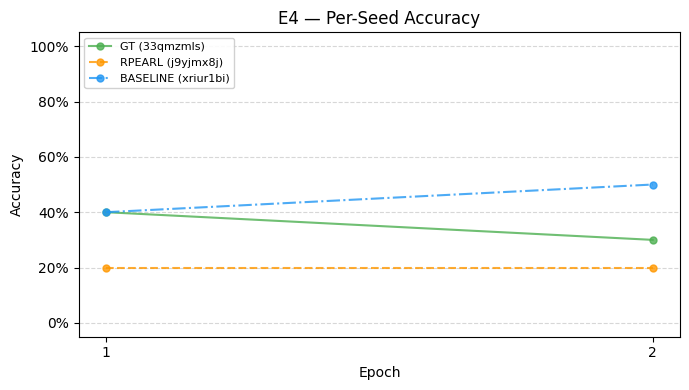

In [46]:
fig, ax = plt.subplots(figsize=(7, 4))

linestyles = ["-", "--", "-.", ":"]

for idx, (run_id, group) in enumerate(df.groupby("run_id")):
    condition = group["condition"].iloc[0]
    color = CONDITION_COLORS[condition]
    ls = linestyles[idx % len(linestyles)]
    sub = group.sort_values("epoch")
    label = f"{condition} ({run_id})"
    ax.plot(
        sub["epoch"], sub["accuracy"],
        marker="o", color=color, linestyle=ls,
        label=label, linewidth=1.5, markersize=5, alpha=0.8,
    )

ax.set_xticks(epochs_all)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E4 — Per-Seed Accuracy")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 3 — Final epoch bar chart

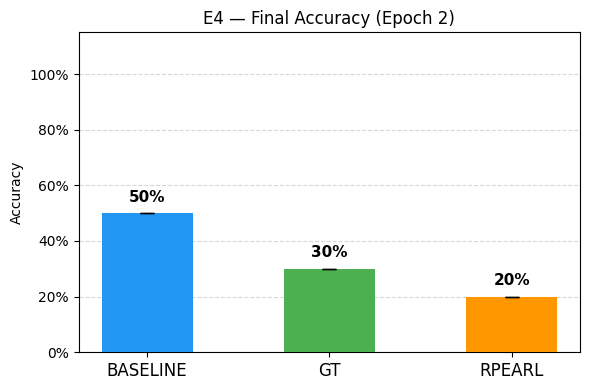

In [47]:
final_epoch = df["epoch"].max()
final = agg[agg["epoch"] == final_epoch].copy()
final = final.set_index("condition").reindex(["BASELINE", "GT", "RPEARL"])

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(final))
bars = ax.bar(
    x, final["mean"],
    color=[CONDITION_COLORS[c] for c in final.index],
    yerr=final["std"], capsize=5,
    width=0.5, zorder=3,
)

for bar, (_, row) in zip(bars, final.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["std"] + 0.03,
        f"{row['mean']*100:.0f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(final.index, fontsize=12)
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.15)
ax.set_title(f"E4 — Final Accuracy (Epoch {final_epoch})")
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

## Summary Table

In [48]:
summary = final[["mean", "std", "n"]].copy()
summary["accuracy"] = summary.apply(
    lambda r: f"{r['mean']*100:.0f}% ± {r['std']*100:.0f}%" if r["n"] > 1 else f"{r['mean']*100:.0f}%",
    axis=1,
)
summary["seeds"] = summary["n"].astype(int)

baseline_acc = final.loc["BASELINE", "mean"]
summary["delta_vs_baseline"] = summary["mean"].apply(
    lambda m: f"{(m - baseline_acc)*100:+.0f}pp"
)

display(summary[["accuracy", "seeds", "delta_vs_baseline"]])

,accuracy,seeds,delta_vs_baseline
condition,,,
BASELINE,50%,1,+0pp
GT,30%,1,-20pp
RPEARL,20%,1,-30pp


## LaTeX Table

In [52]:
latex_df = summary[["accuracy", "seeds", "delta_vs_baseline"]].rename(columns={
    "accuracy": "Accuracy (mean ± std)",
    "seeds": "Seeds",
    "delta_vs_baseline": r"$\Delta$ vs Baseline",
})
latex_df.index.name = "Condition"

print(latex_df.to_latex(
    caption=f"E3 Transferability \\& Permutation Equivariance — Final Accuracy (Epoch {final_epoch})",
    label="tab:e3_accuracy",
    escape=False,
))

\begin{table}
\caption{E3 Transferability \& Permutation Equivariance — Final Accuracy (Epoch 2)}
\label{tab:e3_accuracy}
\begin{tabular}{llrl}
\toprule
 & Accuracy (mean ± std) & Seeds & $\Delta$ vs Baseline \\
Condition &  &  &  \\
\midrule
BASELINE & 50% & 1 & +0pp \\
GT & 30% & 1 & -20pp \\
RPEARL & 20% & 1 & -30pp \\
\bottomrule
\end{tabular}
\end{table}



# DEBUG — 3-way (actually 4-way) eval comparison

The three best E4 checkpoints (`xriur1bi`, `j9yjmx8j`, `33qmzmls`) are evaluated by four
different test sets. The cell below loads each source and builds the comparison table.

Sources:
1. **First-pass training eval** — `outputs/.../eval_logs/step_000394_epoch_2.000.json` (10 tasks)
2. **Sweep cross-eval** — pulled from `best_per_arch` above (`eval_logs/cross_eval/*.json`, 100 tasks)
3. **Transferability N=100 cell** — `results/e4_transferability/perm_{seed}/<ckpt>_eval_graph_unique_100.json` (30 tasks)
4. **New 20-graph N=100 sample** — `results/e4_transferability_n100_deleteme/perm_{seed}/<ckpt>_summary.json` (600 tasks)


,"train-time eval\n(1 graph, N=52)","sweep large test\n(10 graphs, N=33–59)",transfer N=100\n(1 graph),transfer N=100\n(20 graphs)
LLM,0.500 ± 0.527 (n=10),0.340 ± 0.476 (n=100),0.433 ± 0.504 (n=30),0.443 ± 0.497 (n=600)
RPEARL,0.200 ± 0.422 (n=10),0.430 ± 0.498 (n=100),0.633 ± 0.490 (n=30),0.365 ± 0.482 (n=600)
RPEARL_GT,0.300 ± 0.483 (n=10),0.410 ± 0.494 (n=100),0.633 ± 0.490 (n=30),0.395 ± 0.489 (n=600)


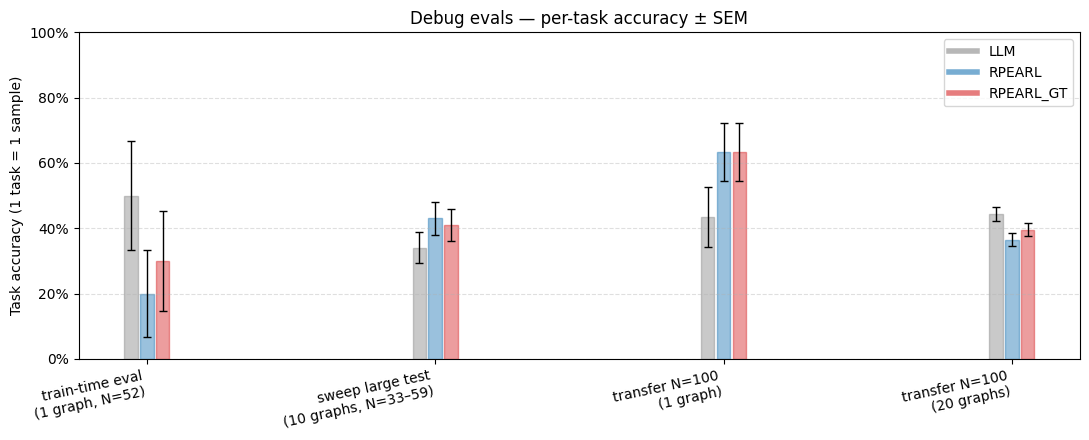

In [56]:
import json, glob, os
from statistics import mean, stdev

DEBUG_CKPTS = {
    "e4_llm_llama-3.1-8b_r16_4bit_xriur1bi":          "LLM",
    "e4_rpearl_llm_llama-3.1-8b_r16_4bit_j9yjmx8j":   "RPEARL",
    "e4_rpearl_gt_llm_llama-3.1-8b_r16_4bit_33qmzmls": "RPEARL_GT",
}
PERMS = [32, 42, 58]
RES = "../results"

def _correct_flags(path):
    """Return per-task correctness as a list of 1/0 ints (1 task = 1 sample)."""
    with open(path) as f: d = json.load(f)
    return [int(bool(s["correct"])) for s in d["samples"]]

# 1) Train-time eval (epoch 2). 1 file × 10 tasks = 10 samples.
first_pass = {
    lbl: _correct_flags(f"{RESULTS_ROOT}/{ck}/eval_logs/step_000394_epoch_2.000.json")
    for ck, lbl in DEBUG_CKPTS.items()
}

# 2) Sweep large test. 10 cross_eval graphs × 10 tasks = 100 samples.
sweep_trials = {}
for ck, lbl in DEBUG_CKPTS.items():
    flags = []
    for fp in sorted(glob.glob(f"{RESULTS_ROOT}/{ck}/eval_logs/cross_eval/*.json")):
        flags += _correct_flags(fp)
    sweep_trials[lbl] = flags

# 3) Transfer N=100 (single graph). 3 perm seeds × 10 tasks = 30 samples.
trans_trials = {}
for ck, lbl in DEBUG_CKPTS.items():
    flags = []
    for p in PERMS:
        flags += _correct_flags(f"{RES}/e4_transferability/perm_{p}/{ck}_eval_graph_unique_100.json")
    trans_trials[lbl] = flags

# 4) Transfer N=100 (20 graphs). 20 graphs × 3 perm seeds × 10 tasks = 600 samples.
broad_trials = {}
for ck, lbl in DEBUG_CKPTS.items():
    flags = []
    for p in PERMS:
        for fp in sorted(glob.glob(f"{RES}/e4_transferability_n100_deleteme/perm_{p}/{ck}_eval_graph_unique_100*.json")):
            flags += _correct_flags(fp)
    broad_trials[lbl] = flags

def _agg(flags):
    """Mean and std over per-task binary outcomes (1 task = 1 sample)."""
    mu = mean(flags)
    sd = stdev(flags) if len(flags) > 1 else float("nan")
    return mu, sd, len(flags)

def _row(lbl, trials_by_eval):
    out = {}
    for col, trials in trials_by_eval:
        mu, sd, n = _agg(trials[lbl])
        out[col] = f"{mu:.3f} ± {sd:.3f} (n={n})"
    return out

debug_evals = [
    ("train-time eval\n(1 graph, N=52)",                first_pass),
    ("sweep large test\n(10 graphs, N=33–59)",          sweep_trials),
    ("transfer N=100\n(1 graph)",                       trans_trials),
    ("transfer N=100\n(20 graphs)",                     broad_trials),
]
debug_labels = ["LLM", "RPEARL", "RPEARL_GT"]

debug_df = pd.DataFrame({
    lbl: _row(lbl, debug_evals) for lbl in debug_labels
}).T
display(debug_df)

DEBUG_COLORS = {"LLM": "#888888", "RPEARL": "#1f77b4", "RPEARL_GT": "#d62728"}

fig, ax = plt.subplots(figsize=(11, 4.5))
group_gap = 1.0
box_w = 0.22
centers = []
tick_labels = []

for gi, (eval_name, trials_by_lbl) in enumerate(debug_evals):
    base = gi * (len(debug_labels) + group_gap) + 1
    centers.append(base + box_w)
    tick_labels.append(eval_name)
    for ci, lbl in enumerate(debug_labels):
        pos = base + ci * box_w
        flags = trials_by_lbl[lbl]
        color = DEBUG_COLORS[lbl]
        mu, sd, n = _agg(flags)
        ax.bar(pos, mu, width=box_w * 0.85, color=color, alpha=0.45, edgecolor=color)
        if sd == sd:
            ax.errorbar(pos, mu, yerr=sd / (n ** 0.5), color="black", capsize=3, lw=1)

ax.set_xticks(centers)
ax.set_xticklabels(tick_labels, rotation=12, ha="right")
ax.set_ylabel("Task accuracy (1 task = 1 sample)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.0)
ax.set_title("Debug evals — per-task accuracy ± SEM")
ax.legend(
    [plt.Line2D([0], [0], color=c, lw=4, alpha=0.6) for c in DEBUG_COLORS.values()],
    DEBUG_COLORS.keys(),
    loc="upper right",
)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## DEBUG — E3 vs E4: are tasks harder, or models worse?

Same four-eval comparison as above, repeated for E3 and E4 best checkpoints. If accuracies drop everywhere from E3 → E4, the new data is harder. If they drop only on some evals, the regression is task-specific.


In [ ]:
import json, glob, os
from statistics import mean, stdev

E3_CKPTS = {
    "e3_llm_llama-3.1-8b_r16_4bit_0sy9j5rz":          "LLM",
    "e3_rpearl_llm_llama-3.1-8b_r16_4bit_qmu8x2qu":   "RPEARL",
    "e3_rpearl_gt_llm_llama-3.1-8b_r16_4bit_bzqt4zxt": "RPEARL_GT",
}
E4_CKPTS = DEBUG_CKPTS  # defined in the cell above

E3_OUT  = "../outputs/e3_new_training_data"
E4_OUT  = RESULTS_ROOT
E3_TRANS = f"{RES}/e3_transferability_betty"
E4_TRANS = f"{RES}/e4_transferability"
PERMS = [32, 42, 58]

def _flags(path):
    with open(path) as f: d = json.load(f)
    return [int(bool(s["correct"])) for s in d["samples"]]

def _last_step(ck_root):
    files = sorted(glob.glob(f"{ck_root}/eval_logs/step_*.json"))
    return files[-1] if files else None

def collect(out_root, trans_root, ckpts):
    """Returns {eval_name: {arch_label: [0/1, ...]}}"""
    train_time, sweep, trans_single = {}, {}, {}
    for ck, lbl in ckpts.items():
        sp = _last_step(f"{out_root}/{ck}")
        train_time[lbl] = _flags(sp) if sp else []
        sweep_flags = []
        for fp in sorted(glob.glob(f"{out_root}/{ck}/eval_logs/cross_eval/*.json")):
            sweep_flags += _flags(fp)
        sweep[lbl] = sweep_flags
        trans_flags = []
        for p in PERMS:
            fp = f"{trans_root}/perm_{p}/{ck}_eval_graph_unique_100.json"
            if os.path.exists(fp):
                trans_flags += _flags(fp)
        trans_single[lbl] = trans_flags
    return train_time, sweep, trans_single

e3_train, e3_sweep, e3_trans = collect(E3_OUT, E3_TRANS, E3_CKPTS)
e4_train, e4_sweep, e4_trans = collect(E4_OUT, E4_TRANS, E4_CKPTS)
# e4 broader 20-graph sample (no e3 equivalent)
e4_broad = broad_trials  # from previous cell

eval_columns = [
    ("train-time\n(1 graph)",            e3_train, e4_train),
    ("sweep large test\n(~10 graphs)",   e3_sweep, e4_sweep),
    ("transfer N=100\n(1 graph)",        e3_trans, e4_trans),
    ("transfer N=100\n(20 graphs)",      None,     e4_broad),
]
labels = ["LLM", "RPEARL", "RPEARL_GT"]
COLORS = DEBUG_COLORS  # from previous cell

# Build table
rows = []
for lbl in labels:
    for gen, gen_name in [("E3", 0), ("E4", 1)]:
        row = {"gen": gen, "arch": lbl}
        for col, e3, e4 in eval_columns:
            src = e4 if gen == "E4" else e3
            if src is None:
                row[col.replace("\n", " ")] = "—"
                continue
            flags = src[lbl]
            mu = mean(flags) if flags else float("nan")
            n = len(flags)
            row[col.replace("\n", " ")] = f"{mu:.3f}  (n={n})" if n else "—"
        rows.append(row)
cmp_df = pd.DataFrame(rows).set_index(["arch", "gen"])
display(cmp_df)

# Plot: grouped bars, E3 (hatched) next to E4 (solid) for each (arch × eval) cell
fig, ax = plt.subplots(figsize=(12, 4.8))
n_evals = len(eval_columns)
n_arch  = len(labels)
inner_gap = 0.05
bar_w   = 0.32
group_w = 2 * bar_w + inner_gap
arch_step = group_w + 0.25
eval_step = arch_step * n_arch + 0.7

x_eval_centers = []
for ei, (col, e3, e4) in enumerate(eval_columns):
    x_eval = ei * eval_step
    arch_centers = []
    for ai, lbl in enumerate(labels):
        x_arch = x_eval + ai * arch_step
        arch_centers.append(x_arch + bar_w / 2 + inner_gap / 2)
        color = COLORS[lbl]
        # E3
        if e3 is not None and e3[lbl]:
            mu = mean(e3[lbl]); n = len(e3[lbl])
            sem = (mu * (1 - mu) / n) ** 0.5
            ax.bar(x_arch, mu, width=bar_w, color=color, alpha=0.35,
                   edgecolor=color, hatch="//", label=f"{lbl} E3" if ei == 0 else None)
            ax.errorbar(x_arch, mu, yerr=sem, color="black", capsize=2, lw=0.8)
        # E4
        if e4 is not None and e4[lbl]:
            mu = mean(e4[lbl]); n = len(e4[lbl])
            sem = (mu * (1 - mu) / n) ** 0.5
            ax.bar(x_arch + bar_w + inner_gap, mu, width=bar_w, color=color, alpha=0.9,
                   edgecolor=color, label=f"{lbl} E4" if ei == 0 else None)
            ax.errorbar(x_arch + bar_w + inner_gap, mu, yerr=sem, color="black", capsize=2, lw=0.8)
    x_eval_centers.append(x_eval + (n_arch * arch_step) / 2 - arch_step / 2)

ax.set_xticks(x_eval_centers)
ax.set_xticklabels([c for c, *_ in eval_columns])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Task accuracy")
ax.set_title("E3 (hatched) vs E4 (solid) — same checkpoints picked best-per-arch, per eval")
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Per-size transferability comparison (a deeper cut)
print("\n--- Transferability accuracy by graph size (perm_42 only) ---")
sizes = [10, 30, 50, 100, 250]
rows2 = []
for lbl in labels:
    for gen, ckpts, root in [("E3", E3_CKPTS, E3_TRANS), ("E4", E4_CKPTS, E4_TRANS)]:
        ck = [c for c, l in ckpts.items() if l == lbl][0]
        row = {"gen": gen, "arch": lbl}
        for sz in sizes:
            fp = f"{root}/perm_42/{ck}_eval_graph_unique_{sz}.json"
            row[f"N={sz}"] = f"{json.load(open(fp))['accuracy']:.2f}" if os.path.exists(fp) else "—"
        rows2.append(row)
display(pd.DataFrame(rows2).set_index(["arch", "gen"]))
